This notebook exists to quantify fidelity metrics for the balanced homodyne simulation, as well as some qualitative tests. These are a few sections:

1. Packages, Basic Helper Functions and QuTiP initialization
2. Timing Jitter Analysis
3. Phase Jitter Analysis
4. Inferring Temporal Mode and Marginals
5. Wigner Function Reconstruction

# Setup
Here, we have packages, helper functions and some initialization functions to reduce time later on. If you already have QuTiP installed, you can skip the next cell.

Please ensure all cells from here to "Timing Jitter" have run before running anything else - all pieces are assumed to have run.

In [45]:
!pip install qutip

In [46]:
import numpy as np
import qutip as qt
import scipy as sp
from scipy import integrate, ndimage, linalg, interpolate
from scipy.ndimage import zoom
from scipy.special import eval_hermite, factorial
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from math import comb, sqrt, pi
from matplotlib import colors
from numpy import random
from skimage.transform import radon, iradon


plt.style.use('default')


rng = random.default_rng()

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 120

In [47]:
def invtrans_sample(cdf, xvals, Nx, Ny):
    '''
        Draws a sample from a probability density fn with cumulative cdf
            using numpy.interp for efficiency.

          - cdf (array): array representing the cumulative distribution of P(x)
          - xvals (array): x values corresponding to cdf(xvals)
          - Nx (int): length of horizontal array
          - Ny (int): length of vertical array

        Returns:
            (array): Nx x Ny array
    '''
    # Generate uniform random number on [0,1)
    u = np.random.rand(Nx, Ny)
    # invert cdf and interpolate to find result
    sample = np.interp(u, cdf, xvals)
    return sample


def generate_basis(y, t):
    '''
        Genenerate an orthonormal basis for the homodyne trace with y as its first element.

      - y: Physical mode
      - t: Time array over which y is defined
    '''
    N = len(y)
    M = np.argmax(np.abs(y)) #location of max of mode
    # Define initial detector basis modes as instants of time

    # Ensure every degree of freedom is occupied
    x = np.zeros([N,N])
    for k in range(M):
        x[k][k+1] = 1
    for k in range(M,N):
        x[k][k] = 1
    x[:,0] = y

    q,r = np.linalg.qr(x)
    q = q.transpose() # allows us to index modes as modes[i]

    # Ensure first mode is of same sign as input mode. If it isn't, the integrated quadrature sample will be negative.
    if np.dot(q[0], y) < 0:
        q[0] = -q[0]

    # Correct normalization: integrate along axis=1 and take sqrt
    norms_squared = integrate.trapezoid(q**2, x=t, axis=1)
    norms = np.sqrt(norms_squared)
    # Reshape norms for broadcasting across all columns of q
    q = q / norms[:, np.newaxis]
    q[1] = q[1]/np.sqrt(2)
    q[-1] = q[-1]/np.sqrt(2)

    return q

def gen_photocurrent(modes, cdf, cdf_bg, xvec, Ntraces, scl=1, noise=None, pdf_x=None, noise_pdf=False):
    '''
        Simulate N time domain trace from a homodyne detector.

      - modes:      a set of orthonormal modes from generate_basis()
      - cdf:        the cumulative distribution corresponding to the quantum state
      - cdf_bg:     the background state cdf. Normally this is the vacuum but could be thermal
      - xvec:       the quadrature vector the simulation is defined on
      - Ntraces:    The number of traces to generate
      - scl:        can scale the entire homodyne photocurrent by this value. Usually 1.
      - noise:      Standard deviation of Gaussian noise. If other kinds of noise are desired,
                        an array representing the noise PDF can be input. In this case,
                        ensure noise_pdf = True
      - pdf_x:      The x-axis (quadrature) vector corresponding to the noise PDF.
                        Used for interpolation if provided.
      - noise_pdf:  Set True if inputting an array corresponding to the noise PDF. Otherwise
                        function will assume gaussian and fail to draw samples.
    '''
    Npts = len(modes) # Number of points in each photocurrent trace

    # Generate the quadrature coefficients
    q0_coeffs_mode0 = invtrans_sample(cdf, xvec, Ntraces, 1) # One sample drawn from cdf
    q0_coeffs_other_modes = invtrans_sample(cdf_bg, xvec, Ntraces, Npts - 1) # Rest drawn from background

    q0 = np.concatenate((q0_coeffs_mode0, q0_coeffs_other_modes), axis=1) # Shape (Ntraces, Npts)

    ihd = np.matmul(q0, modes) # Generate traces as a matrix

    # Adding noise
    if noise is not None:
        if noise_pdf:
            # Determine the source x-axis for the noise PDF
            source_x = pdf_x if pdf_x is not None else np.linspace(xvec[0], xvec[-1], len(noise))

            # Interpolate noise to simulation xvec
            noise_interp = np.interp(xvec, source_x, noise)

            # Re-normalize any interpolation error using trapezoidal rule
            area = integrate.trapezoid(noise_interp, xvec)
            noise_interp /= area

            # Convert to CDF and sample
            noise_cdf = marge_to_cdf(noise_interp)
            noise_samples = invtrans_sample(noise_cdf, xvec, Ntraces, Npts)
            ihd = ihd + noise_samples

        else:
            # If noise is a float/int, assume gaussian with width 'noise'
            ihd = ihd + rng.normal(0, noise, ihd.shape)

    return ihd * scl

def W_to_marge(W, theta, xvec):
    '''
        Generate a marginal distribution of the given Wigner function at
        phase angle theta using the Radon transform.

        Returns an array of the same length as xvec, effectively mapping
        the rotated projection back onto the original simulation grid.

      - W: Input wigner function (square 2D array)
      - theta: Angle along which to integrate (in radians)
      - xvec: array over which W is defined in one dimension
    '''
    dx = xvec[1] - xvec[0]

    sinogram = radon(W, theta=[np.degrees(theta)], circle=False)
    projection = sinogram[:, 0]

    N_proj = len(projection)
    x_proj = (np.arange(N_proj) - N_proj // 2) * dx

    marge = np.interp(xvec, x_proj, projection, left=0, right=0)

    norm = integrate.simpson(marge, x=xvec)
    if norm > 1e-15:
        marge /= norm

    return marge


def marge_to_cdf(marge):
    '''
        Takes marginal and returns cdf of same length

        Often, we bypass this as it only works for 1 marginal while we usually
            want to integrate N at once.
    '''
    cdf_unnorm = integrate.cumulative_trapezoid(marge, initial=0)
    cdf = cdf_unnorm/cdf_unnorm[-1] # ensure normalization
    return cdf


def state_to_objects(state, x, p, theta = 0):
    '''
        Takes a QuTiP state and returns wigner function, marginal and cdf
      - state: QuTiP state
      - x: array of x values
      - p: array of p values
      - theta: phase angle for marginal
    '''
    W = qt.wigner(state,x,p)
    marge = W_to_marge(W, theta, x)
    cdf = marge_to_cdf(marge)
    return W, marge, cdf

In [48]:
# COMMON TEMPORAL MODES

def square(t, a, b):
    '''
        Return an L^2 normalized rectangular wave with positive value
            between a and b, 0 otherwise

          - t : time array
          - a : start of wave
          - b : end of wave
    '''
    if b <= a:
        raise ValueError("Wave must end after it starts: a < b")
    y = np.zeros_like(t)
    for i in range(len(t)):
        if t[i] >= a and t[i] <= b:
            y[i] = 1
    return y/np.sqrt(b-a)

def gaussian_env(t, mu, sigma):
    y = np.exp(-(t-mu)**2/(2*sigma**2))
    return y/np.sqrt(integrate.simpson(y**2, x=t))

In [49]:
# BASIC SETUP: QUANTUM STATES

dim = 20 # dimension of fock space
x = np.linspace(-8,8,801)
p = np.linspace(-8,8,801)

bg = qt.fock(dim, 0) # vacuum state
bg_W, bg_marge, bg_cdf = state_to_objects(bg, x, p, 0)

co = qt.coherent(dim, 2) # basic coherent state
co_W, co_marge, co_cdf = state_to_objects(co, x, p, 0)

fock1 = qt.fock(dim, 1) # 1-photon fock state
fock1_W, fock1_marge, fock1_cdf = state_to_objects(fock1, x, p, 0)

fock2 = qt.fock(dim, 2) # 2-photon fock state
fock2_W, fock2_marge, fock2_cdf = state_to_objects(fock2, x, p, 0)

cat = (qt.coherent(dim, 2) + qt.coherent(dim, -2)).unit() # cat state w/ alpha = 2
cat_W, cat_marge, cat_cdf = state_to_objects(cat, x, p, 0)

sqvac= qt.squeeze(dim, 0.5)*qt.fock(dim, 0) # squeezed vacuum, xi = 1
sqvac_W, sqvac_marge, sqvac_cdf = state_to_objects(sqvac, x, p, 0)

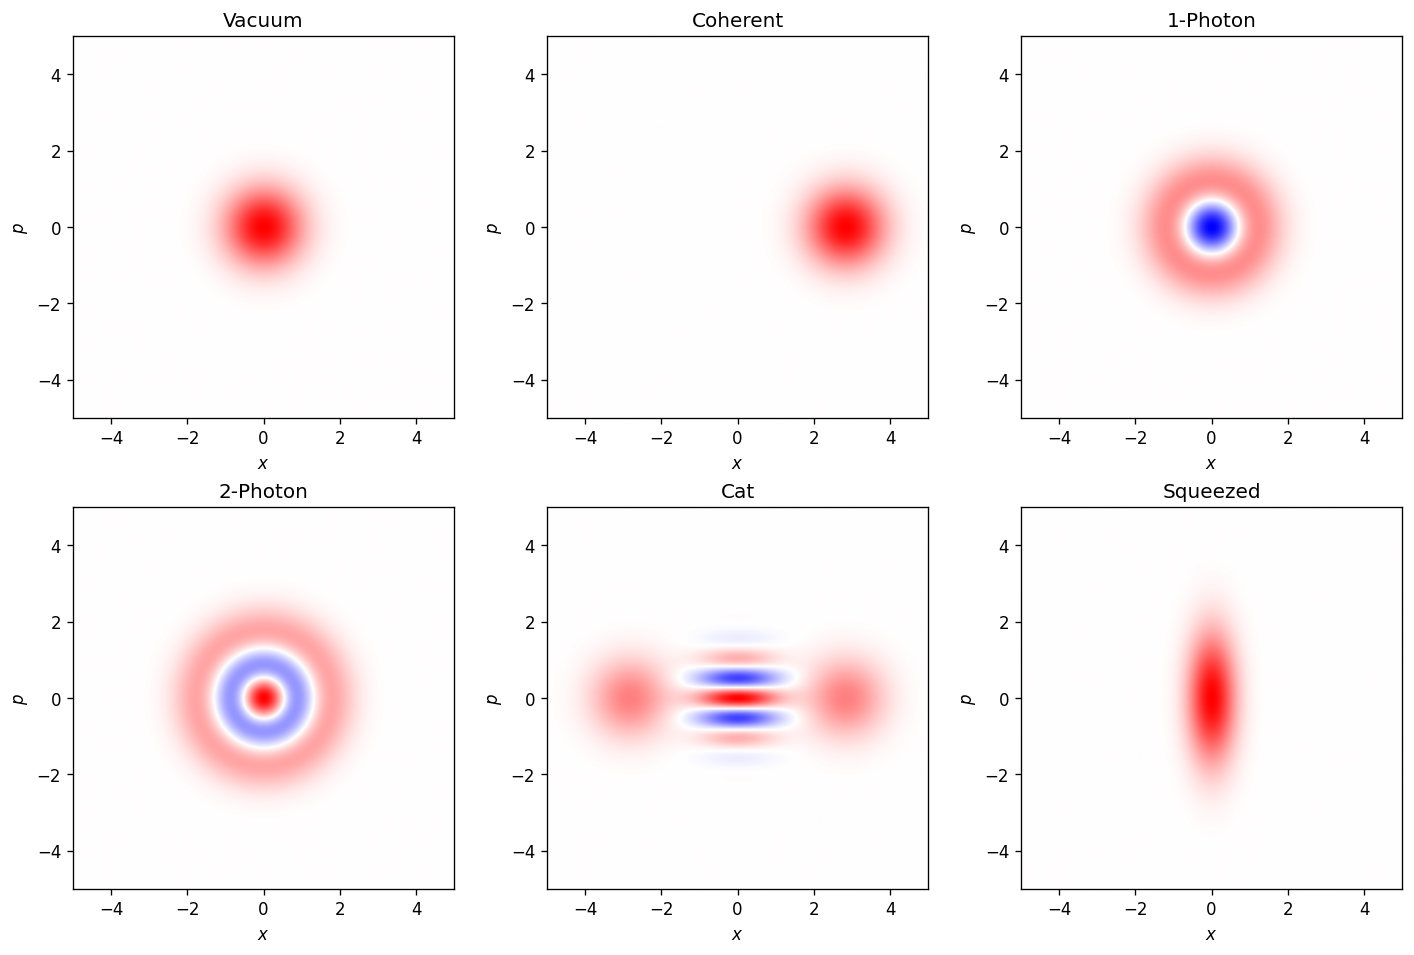

In [50]:
# Plot wigner functions to make sure everything is working correctly

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax = ax.flatten()

wigners = {'Vacuum'     : bg_W,
           'Coherent'   : co_W,
           '1-Photon'   : fock1_W,
           '2-Photon'   : fock2_W,
           'Cat'        : cat_W,
           'Squeezed'   : sqvac_W}

vmax = np.max(np.abs(list(wigners.values())))
for i, title in enumerate(wigners):
    if i == 0:
        norm = colors.Normalize(vmin=-vmax, vmax=vmax)
    vmax = np.max(np.abs(wigners[title]))
    im = ax[i].imshow(wigners[title], extent=[-8,8,-8,8], origin='lower', cmap='bwr', norm=norm)
    ax[i].set_title(title)
    ax[i].set_xlim(-5,5)
    ax[i].set_ylim(-5,5)
    ax[i].set_xlabel('$x$')
    ax[i].set_ylabel('$p$')

plt.tight_layout() # if plot is glitching, comment this out.
plt.savefig('wigners.svg')

In [51]:
# BASIC SETUP: TEMPORAL MODES

t = np.linspace(-20,20,401) # time domain for trace

gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)

In [52]:
# Define States in a manner easy to access

quantum_states_data = {
    'Vacuum State': {'state_object': bg, 'marge': bg_marge, 'cdf': bg_cdf, 'label': 'Vacuum'},
    'Coherent State': {'state_object': co, 'marge': co_marge, 'cdf': co_cdf, 'label': 'Coherent'},
    'Fock 1 State': {'state_object': fock1, 'marge': fock1_marge, 'cdf': fock1_cdf, 'label': 'Fock 1-Photon'},
    'Fock 2 State': {'state_object': fock2, 'marge': fock2_marge, 'cdf': fock2_cdf, 'label': 'Fock 2-Photon'},
    'Cat State': {'state_object': cat, 'marge': cat_marge, 'cdf': cat_cdf, 'label': 'Cat State'},
    'Squeezed Vacuum State': {'state_object': sqvac, 'marge': sqvac_marge, 'cdf': sqvac_cdf, 'label': 'Squeezed Vacuum'}
}

# Mode Overlap

The `fidelity_mode()` function is only used here for ease-of-use. It only works for assessing two specific mode mismatch cases.

In [53]:
def fidelity_mode(gen_modes, meas_mode, state_marge, state_cdf, bg_cdf, N_samps, x_arr, t_arr, bins: int = 100):
    '''
        Return the Bhattacharyya coefficient of a histogram generated with N_samps photocurrent traces.
            Bin number is re-definable in case the data set needs more or less.

      - gen_modes: The generating mode basis generated with generate_basis()
      - meas_mode: The measurement mode
      - state_marge: The marginal of the state of interest
      - state_cdf: The cdf of the state of interest
      - bg_cdf: The cdf of the background state (vacuum or thermal)
      - N_samps: The number of traces to take
      - x_arr: The x-axis of the marginals
      - t_arr: The t-axis of the trace
      - bins: The number of bins to use in the histogram/Bhattacharyya coefficient calculation
    '''
    if len(t_arr) != len(gen_modes[0]) or len(t_arr) != len(meas_mode):
        raise ValueError("Modes must be defined over t_arr")


    # Generate current traces, integrate against our measuring mode
    currents = np.zeros([N_samps,len(t_arr)])
    currents[:] = gen_photocurrent(gen_modes, state_cdf, bg_cdf, x_arr, N_samps)

    y = integrate.trapezoid(currents*meas_mode, x=t_arr, axis=1)


    # Ensure we generate bins over the same x-range as the theoretical marginal
    hist_range = (np.min(x_arr), np.max(x_arr))

    # Generate histogram of integrated trace values
    exp_pdf, bin_edges = np.histogram(y, bins=bins, range=hist_range, density=True)

    # Bin theoretical marginals at the center of the histogram's bins
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    dx = bin_centers[1] - bin_centers[0]

    theory_pdf_interp = np.interp(bin_centers, x_arr, state_marge, left=0, right=0)


    # Compute fidelity as Bhattacharyya Coefficient / L^{1/2} inner product
    fidelity_val = np.sum(np.sqrt(exp_pdf * theory_pdf_interp) * dx)

    return fidelity_val

In [63]:
Nsamps = 100000

# Re-define t_arr, mus, gen_mode, and modes to ensure consistency for this specific task
t = np.linspace(-20,20,400) # t-axis of Trace
mus1 = np.arange(-5, -2.5, 0.5) # step1
mus2 = np.arange(-2.5, 0.05, 0.05) # step2 0.05 ideally
mus = np.concatenate((mus1, mus2))
gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)

fidelity_results = {}

for state_name, state_data in quantum_states_data.items():
    print(f'Processing {state_name}')
    state_marge = state_data['marge']
    state_cdf = state_data['cdf']
    state_label = state_data['label']

    current_state_fidelities = []
    for mu_val in mus:
        meas_mode = gaussian_env(t, mu_val, 1)
        fidelity_val = fidelity_mode(modes, meas_mode, state_marge, state_cdf, bg_cdf, Nsamps, x, t, bins=250)
        current_state_fidelities.append(fidelity_val)
        print(f'\rProcessed mu = {mu_val:.4f}', end='')

    fidelity_results[state_label] = np.array(current_state_fidelities)
    print(f'\rProcessed {state_name}\n\n  ---------------    \n')

print('Fidelity calculations for all states completed')

Processing Vacuum State
Processed Vacuum State

  ---------------    

Processing Coherent State
Processed Coherent State

  ---------------    

Processing Fock 1 State
Processed Fock 1 State

  ---------------    

Processing Fock 2 State
Processed Fock 2 State

  ---------------    

Processing Cat State
Processed Cat State

  ---------------    

Processing Squeezed Vacuum State
Processed Squeezed Vacuum State

  ---------------    

Fidelity calculations for all states completed


In [64]:
eta_mu = np.zeros_like(mus)
for i, mu_val in enumerate(mus):
    # Re-use gen_mode and gaussian_env with the same t_arr and parameters as for fidelity calculation
    eta_mu[i] = integrate.simpson(gen_mode * gaussian_env(t, mu_val, 1), x=t)

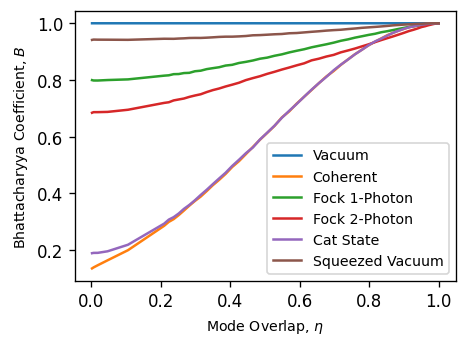

In [65]:
plt.figure(figsize=(4, 3))

for i, (state_name, state_data) in enumerate(quantum_states_data.items()):
    state_label = state_data['label']
    fidelities = fidelity_results[state_label]
    plt.plot(eta_mu, fidelities, label=state_label)





plt.xlabel(r'Mode Overlap, $\eta$', fontsize=8.5)
plt.ylabel('Bhattacharyya Coefficient, $B$', fontsize=8.5)
plt.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig('fidelity_modeoverlap.pdf')
plt.show()

In [66]:
tau = 1.0
target_state_label = 'Fock 1-Photon'
target_state_data = quantum_states_data['Fock 1 State']

meas_mode = gaussian_env(t, tau, 1)
eta = integrate.simpson(gen_mode * meas_mode, x=t)

Nsamps_sim = 200000
sim_currents = gen_photocurrent(modes, target_state_data['cdf'], bg_cdf, x, Nsamps_sim)
samples_mismatched = integrate.trapezoid(sim_currents * meas_mode, x=t, axis=1)

sigma_vac = np.sqrt(1 - eta**2)


# Convolve PDFs to find theoretical marginal of mode overlap
x_state_scaled = x * eta
x_vac_scaled = x * sigma_vac

p_s = np.interp(x, x_state_scaled, target_state_data['marge'], left=0, right=0) / eta
p_v = np.interp(x, x_vac_scaled, bg_marge, left=0, right=0) / sigma_vac

effective_marge_raw = np.convolve(p_s, p_v, mode='same') * (x[1] - x[0])
effective_marge = effective_marge_raw / integrate.simpson(effective_marge_raw, x=x)

vac_marge = bg_marge
state_marge = target_state_data['marge']

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4462/1029944028.py:5: SyntaxWarning: invalid escape sequence '\e'
  ax1.plot(effective_marge, x, label=f'$\eta={eta:.3f}$ Marginal', lw=2, c='tab:orange', zorder=10)


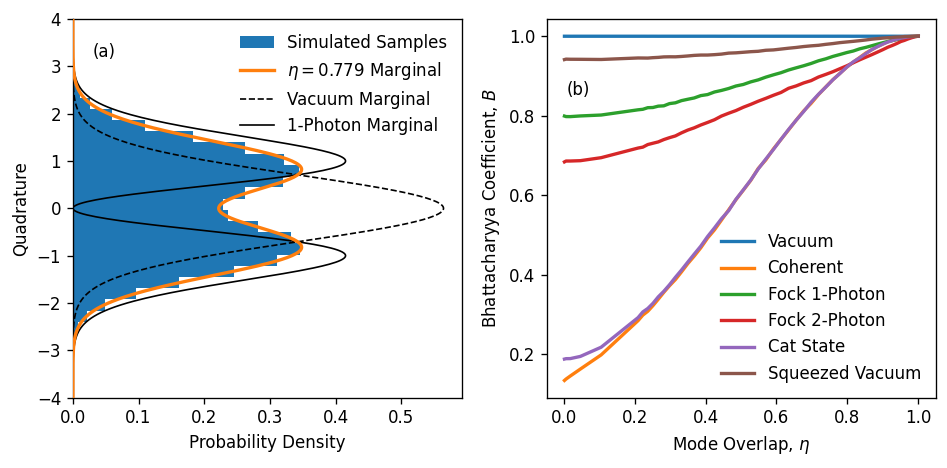

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.hist(samples_mismatched, bins=30, density=True, orientation='horizontal', label='Simulated Samples', zorder=0)

ax1.plot(effective_marge, x, label=f'$\eta={eta:.3f}$ Marginal', lw=2, c='tab:orange', zorder=10)
ax1.plot(vac_marge, x, label='Vacuum Marginal', ls='--', c='black', lw=1)
ax1.plot(state_marge, x, label='1-Photon Marginal', c='black', lw=1)

ax1.set_xlabel('Probability Density')
ax1.set_ylabel('Quadrature')
ax1.set_ylim(-4, 4)
ax1.set_xlim(left=0)
ax1.legend(frameon=0)
ax1.annotate('(a)', [0.05, 0.9], xycoords='axes fraction')

for state_label, fidelities in fidelity_results.items():
    ax2.plot(eta_mu, fidelities, label=state_label, lw=2)

ax2.set_xlabel(r'Mode Overlap, $\eta$')
ax2.set_ylabel('Bhattacharyya Coefficient, $B$')
ax2.legend(frameon=0)
ax2.annotate('(b)', [0.05, 0.8], xycoords='axes fraction')

plt.tight_layout()
plt.savefig('modeoverlap_twopanel.png')
plt.show()

# Timing Jitter
In our case, timing jitter causes the generating modes to be shifted by some time $\tau$. We assume this noise to be normally distributed.

As all of the modes are shifted by the same $\tau$, the effect of timing jitter is equivalent to jitter in the measuring mode - that is, instead of integrating

$$\int_{-\infty}^\infty h(t)\sum_{i=1}^np_i\phi_i(t)dt,$$

we integrate (noting the linearity and finiteness of the integral)

$$\int_{-\infty}^\infty h(t-\tau)\sum_{i=1}^np_i\phi_i(t)dt = \sum_{i=1}^np_i \int_{-\infty}^\infty h(t-\tau)\phi_i(t)dt$$

for a normally distributed sampling of $\tau$ values. We note that this is also a convolution integral, which illustrates our reasoning that we could swap the delay from $\phi$ to $h$.

In [55]:
# Compute fidelities for each state.

Nsamps = 100000
Nsigs = 51
sigmas = np.linspace(0, 10, Nsigs)

bins_hist = 250
hist_range = (np.min(x), np.max(x))

# Redefine gen_mode in case it has been redefined in memory
gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)

fidelity_results = {}

for state_name, state_data in quantum_states_data.items():
    state_marge = state_data['marge']
    state_cdf = state_data['cdf']
    state_label = state_data['label']

    current_state_fidelities = []
    print(f'\nCalculating fidelity for {state_label}...')

    for i, sig in enumerate(sigmas):
        tau_vals = rng.normal(0, sig, size = Nsamps)

        meas_modes = np.zeros((Nsamps, len(t)))
        for j, tau in enumerate(tau_vals):
            meas_modes[j,:] = gaussian_env(t, tau, 1)

        # Generate photocurrent traces
        simulated_currents = gen_photocurrent(modes, state_cdf, bg_cdf, x, Nsamps)

        # Integrate traces against the jittered measuring modes
        y_integrated = integrate.trapezoid(simulated_currents * meas_modes, x=t, axis=1)

        # Generate quadrature histogram
        exp_pdf_simulated, bin_edges = np.histogram(y_integrated, bins=bins_hist,
                                                    range=hist_range, density=True)

        # Bin theoretical marginal
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        dx_hist = bin_centers[1] - bin_centers[0]
        theory_pdf_interp = np.interp(bin_centers, x, state_marge, left=0, right=0)

        # Compute Bhattacharyya Coefficient (np.maximum acts element-wise)
        current_simulated_fidelity = np.sum(np.sqrt(np.maximum(0, exp_pdf_simulated) * np.maximum(0, theory_pdf_interp))) * dx_hist
        current_state_fidelities.append(current_simulated_fidelity)

        print(f'\r    Processed {i+1}/{len(sigmas)} jitter stddevs for {state_label}. Current stddev = {sig:.2f}', end='')

    fidelity_results[state_label] = np.array(current_state_fidelities)

print('\n\nFidelity calculations for all states and jitter distributions complete.')


Calculating fidelity for Vacuum...
    Processed 45/51 jitter stddevs for Vacuum. Current stddev = 8.80

/tmp/ipykernel_4462/193370972.py:22: RuntimeWarning: divide by zero encountered in divide
  return y/np.sqrt(integrate.simpson(y**2, x=t))
/tmp/ipykernel_4462/193370972.py:22: RuntimeWarning: invalid value encountered in divide
  return y/np.sqrt(integrate.simpson(y**2, x=t))
/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadrature.py:149: RuntimeWarning: invalid value encountered in add
  d * (y[tuple(slice1)] + y[tuple(slice2)]) / 2.0,


    Processed 50/51 jitter stddevs for Vacuum. Current stddev = 9.80

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


    Processed 51/51 jitter stddevs for Vacuum. Current stddev = 10.00
Calculating fidelity for Coherent...
    Processed 51/51 jitter stddevs for Coherent. Current stddev = 10.00
Calculating fidelity for Fock 1-Photon...
    Processed 51/51 jitter stddevs for Fock 1-Photon. Current stddev = 10.00
Calculating fidelity for Fock 2-Photon...
    Processed 51/51 jitter stddevs for Fock 2-Photon. Current stddev = 10.00
Calculating fidelity for Cat State...
    Processed 51/51 jitter stddevs for Cat State. Current stddev = 10.00
Calculating fidelity for Squeezed Vacuum...
    Processed 51/51 jitter stddevs for Squeezed Vacuum. Current stddev = 10.00

Fidelity calculations for all states and jitter distributions complete.


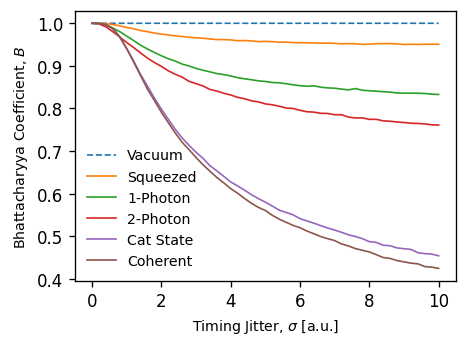

In [56]:
plt.figure(figsize=(4, 3))

plt.plot(sigmas, fidelity_results['Vacuum'], linestyle='--',
         label='Vacuum', linewidth=1) #plot vacuum to ensure it is equal to 1 always
plt.plot(sigmas, fidelity_results['Squeezed Vacuum'], linestyle='-',
         label='Squeezed', linewidth=1)
plt.plot(sigmas, fidelity_results['Fock 1-Photon'], linestyle='-',
         label='1-Photon', linewidth=1)
plt.plot(sigmas, fidelity_results['Fock 2-Photon'], linestyle='-',
         label='2-Photon', linewidth=1)
plt.plot(sigmas, fidelity_results['Cat State'], linestyle='-',
         label='Cat State', linewidth=1)
plt.plot(sigmas, fidelity_results['Coherent'], linestyle='-',
         label='Coherent', linewidth=1)



plt.xlabel(r'Timing Jitter, $\sigma$ [a.u.]', fontsize=8.5)
plt.ylabel('Bhattacharyya Coefficient, $B$', fontsize=8.5)
plt.legend(loc='lower left', fontsize=8.5, frameon=False)
plt.tight_layout()
plt.show()

# Phase Jitter
We define phase jitter as an error $\delta \theta$ in the angle along which we integrate our Wigner function to obtain our marginal. We begin our simulation by pre-computing the marginal of the given Wigner function for a number of angles from $-\pi\to\pi$ using the Radon transform. The more complex the state, the more of these lookup marginals should be produced. Because phase jitter does not affect rotationally symmetric states, we redefine `quantum_states_data` to avoid unnecessary computation.

Furthermore, to reduce computation time, we directly sample the marginals rather than producing a trace and integrating it. As there is no timing jitter, this does not affect results.

In [57]:
# Redefine gen_mode in case it has been redefined in memory
gen_mode = gaussian_env(t, 0, 1)
modes = generate_basis(gen_mode, t)
meas_mode_ideal = gen_mode

# Select only non-symmetric states
phase_quantum_states_data = {
    'Squeezed Vacuum State': {'state_object': sqvac, 'marge': sqvac_marge, 'cdf': sqvac_cdf, 'label': 'Squeezed'},
    'Cat State': {'state_object': cat, 'marge': cat_marge, 'cdf': cat_cdf, 'label': 'Cat'},
    'Coherent State': {'state_object': co, 'marge': co_marge, 'cdf': co_cdf, 'label': 'Coherent'}
}

In [58]:
# Pre-compute marginals for all states
N_lookup = 1000
lookup_thetas = np.linspace(-np.pi, np.pi, N_lookup)
lookup_thetas_deg = np.degrees(lookup_thetas)

precomputed_cdfs = {}
precomputed_ideals = {}

print("Pre-computing Radon transforms for all states...")

for state_name, state_data in phase_quantum_states_data.items():
    # Get base Wigner at theta=0
    W_base, _, _ = state_to_objects(state_data['state_object'], x, p, 0)

    # Compute marginals for all angles
    marginals = radon(W_base, theta=lookup_thetas_deg, circle=False)

    # Interpolate output to x
    dx = x[1] - x[0]
    r_rows = marginals.shape[0]
    x_radon = (np.arange(r_rows) - r_rows // 2) * dx

    interpol = interpolate.interp1d(x_radon, marginals, axis=0,
                                        kind='linear', bounds_error=False, fill_value=0)
    marginals_aligned = interpol(x)

    # Renormalize marginals
    areas = integrate.simpson(marginals_aligned, dx=dx, axis=0)
    areas[areas < 1e-10] = 1.0 # Avoid div/0
    pdfs = marginals_aligned / areas[np.newaxis, :]

    # Compute CDFs
    cdfs = integrate.cumulative_trapezoid(pdfs, x, axis=0, initial=0)
    cdfs /= cdfs[-1, :] # Ensure they end at exactly 1.0

    precomputed_cdfs[state_data['label']] = cdfs

    # Store ideal marginal for later use
    precomputed_ideals[state_data['label']] = state_data['marge']
    print(f'    Completed {state_name}')

print("Pre-computation complete.")

Pre-computing Radon transforms for all states...
    Completed Squeezed Vacuum State
    Completed Cat State
    Completed Coherent State
Pre-computation complete.


In [59]:
Nsamps_per_sigma = 100000 # samples/jitter
Nsigs = 50 # number of jitter stddevs
sigmas_dth = np.linspace(0, np.pi, Nsigs)

bins_hist = 100 # bins for Bhattacharyya Coefficient Computation
hist_range = (np.min(x), np.max(x))
dx = x[1] - x[0]

fidelity_results_phase_jitter_dist = {}

for state_name, state_data in phase_quantum_states_data.items():
    state_label = state_data['label']
    lookup_table = precomputed_cdfs[state_label]
    ideal_marginal = precomputed_ideals[state_label]

    current_state_fidelities = np.zeros(Nsigs)
    print(f"\nSimulating {state_label}...")

    for i, sig_dth in enumerate(sigmas_dth):
        # Sample N random phase shifts from Gaussian
        dth_vals = rng.normal(0, sig_dth, size=Nsamps_per_sigma)

        # Wrap jitter to [-pi,pi]
        dth_vals = (dth_vals + np.pi) % (2 * np.pi) - np.pi

        # Find nearest index in the lookup table
        idx_step = lookup_thetas[1] - lookup_thetas[0]
        indices = np.round((dth_vals - lookup_thetas[0]) / idx_step).astype(int)
        indices = np.clip(indices, 0, N_lookup - 1)

        # Optimized Batch Sampling
        u_vals = rng.random(Nsamps_per_sigma)
        batch_cdfs = lookup_table[:, indices]

        # Efficient interpolation across the batch
        # We iterate over the columns but use the pre-indexed batch_cdfs array
        samples = np.array([np.interp(u_vals[k], batch_cdfs[:, k], x) for k in range(Nsamps_per_sigma)])

        # Histogram the samples
        exp_pdf, bin_edges = np.histogram(samples, bins=bins_hist,
                                          range=hist_range, density=True)

        # Bin theoretical marginal
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        dx_hist = bin_centers[1] - bin_centers[0]
        theory_pdf = np.interp(bin_centers, x, ideal_marginal, left=0, right=0)

        # Compute Bhattacharyya Coefficient
        fid = np.sum(np.sqrt(np.maximum(0, exp_pdf) * np.maximum(0, theory_pdf))) * dx_hist
        current_state_fidelities[i] = fid

        print(f'\r    {i+1}/{Nsigs} ({sig_dth:.2f} rad)', end='')

    fidelity_results_phase_jitter_dist[state_label] = current_state_fidelities

print("\ndone")


Simulating Squeezed...
    50/50 (3.14 rad)
Simulating Cat...
    50/50 (3.14 rad)
Simulating Coherent...
    50/50 (3.14 rad)
done


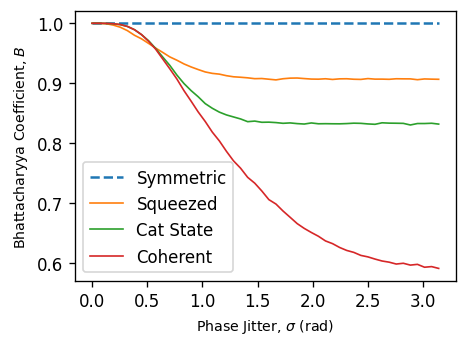

In [60]:
plt.figure(figsize=(4,3))

plt.plot(sigmas_dth, np.ones_like(sigmas_dth), linestyle='--', label='Symmetric')
plt.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Squeezed'],
         linestyle='-', label='Squeezed', linewidth=1)
plt.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Cat'],
         linestyle='-', label='Cat State', linewidth=1)
plt.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Coherent'],
         linestyle='-', label='Coherent', linewidth=1)



plt.xlabel(r'Phase Jitter, $\sigma$ (rad)', fontsize=8.5)
plt.ylabel(r'Bhattacharyya Coefficient, $B$', fontsize=8.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Jitter Combined Plots

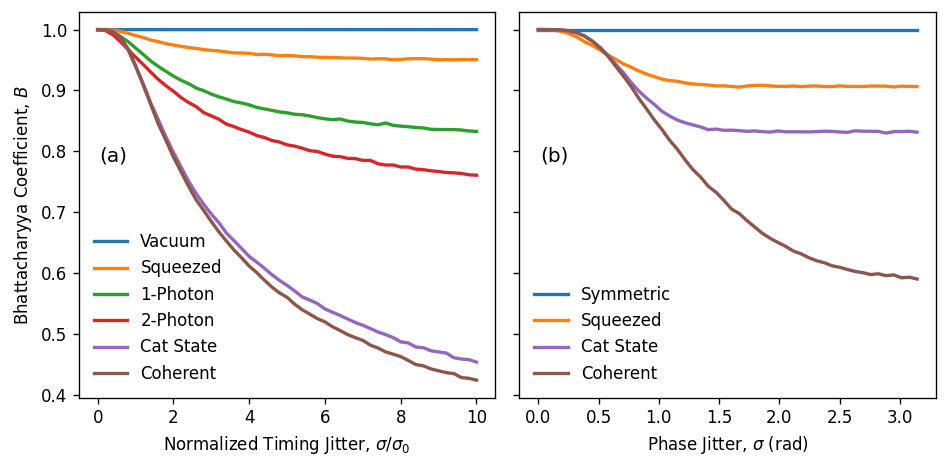

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# --- LEFT PANEL: Timing Jitter ---
ax1.plot(sigmas, fidelity_results['Vacuum'], label='Vacuum', lw=2)
ax1.plot(sigmas, fidelity_results['Squeezed Vacuum'], label='Squeezed', lw=2)
ax1.plot(sigmas, fidelity_results['Fock 1-Photon'], label='1-Photon', lw=2)
ax1.plot(sigmas, fidelity_results['Fock 2-Photon'], label='2-Photon', lw=2)
ax1.plot(sigmas, fidelity_results['Cat State'], label='Cat State', lw=2)
ax1.plot(sigmas, fidelity_results['Coherent'], label='Coherent', lw=2)

ax1.set_xlabel(r'Normalized Timing Jitter, $\sigma/\sigma_0$')
ax1.set_ylabel(r'Bhattacharyya Coefficient, $B$')
ax1.legend(loc='lower left', frameon=False)
ax1.annotate('(a)', xy=(0.05, 0.65), xycoords='axes fraction', fontsize=12, va='top')

# --- RIGHT PANEL: Phase Jitter ---
ax2.plot(sigmas_dth, np.ones_like(sigmas_dth), label='Symmetric', lw=2)
ax2.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Squeezed'], label='Squeezed', lw=2)
ax2.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Cat'], label='Cat State', c='tab:purple', lw=2)
ax2.plot(sigmas_dth, fidelity_results_phase_jitter_dist['Coherent'], label='Coherent', c='tab:brown', lw=2)

ax2.set_xlabel(r'Phase Jitter, $\sigma$ (rad)')
ax2.legend(loc='lower left', frameon=False)
ax2.annotate('(b)', xy=(0.05, 0.65), xycoords='axes fraction', fontsize=12, va='top')

plt.tight_layout()
plt.savefig('bothjitters.pdf')
plt.show()

# Inferring Modes and Marginals

Because an arbitrary state carries more variance in its quadrature than the vacuum, plotting the pointwise variance of the photocurrents will reveal the mode containing the state. Furthermore, we can infer the marginal by histogramming our output data.

In [68]:
gen_mode = gaussian_env(t, 0, 1) #play around with this!
modes = generate_basis(gen_mode, t)

Nsamps = 50000
traces_1photon = gen_photocurrent(modes, fock1_cdf, bg_cdf, x, Nsamps)
traces_vac = gen_photocurrent(modes, bg_cdf, bg_cdf, x, Nsamps)

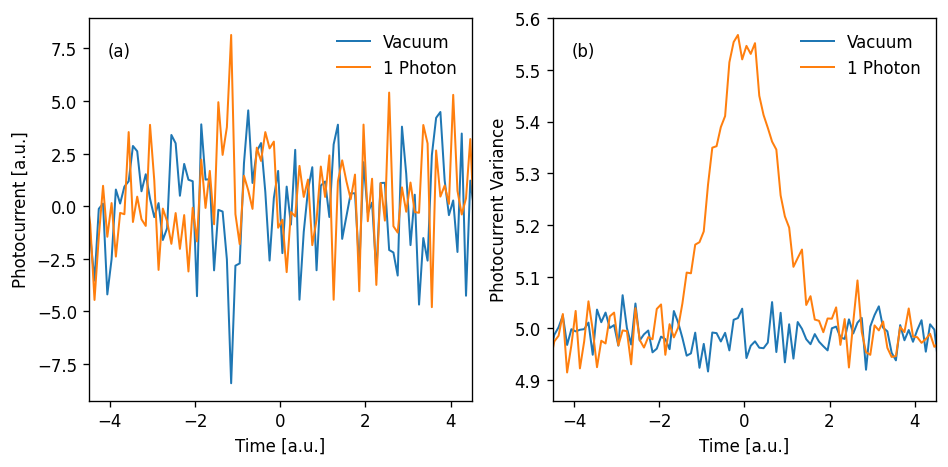

In [69]:
var_1photon = np.var(traces_1photon, axis=0)
var_vac = np.var(traces_vac, axis=0)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(t[100:350], traces_vac[21][100:350], label=r'Vacuum', linewidth=1.2)
ax[0].plot(t[100:350], traces_1photon[28][100:350], label=r'1 Photon',color='tab:orange', linewidth=1.2)
ax[0].legend(frameon = False)
#ax[0].set_title('Simulated BHD Photocurrent')
ax[0].set_xlabel('Time [a.u.]')
ax[0].set_ylabel('Photocurrent [a.u.]')
ax[0].set_xlim(-4.5,4.5)
ax[0].annotate('(a)',[0.05,0.9], xycoords='axes fraction')

ax[1].plot(t[100:350], var_vac[100:350], label=r'Vacuum', linewidth=1.2)
ax[1].plot(t[100:350], var_1photon[100:350], label=r'1 Photon', color='tab:orange', linewidth=1.2)
ax[1].legend(frameon = False)
#ax[1].set_title(r'Pointwise Variance over $5\times10^4$ Traces')
ax[1].set_xlabel('Time [a.u.]')
ax[1].set_ylabel('Photocurrent Variance')
ax[1].set_xlim(-4.5,4.5)
ax[1].annotate('(b)',[0.05,0.9], xycoords='axes fraction')

plt.tight_layout()

plt.savefig('sim_current_PWRvar_NEW.png')

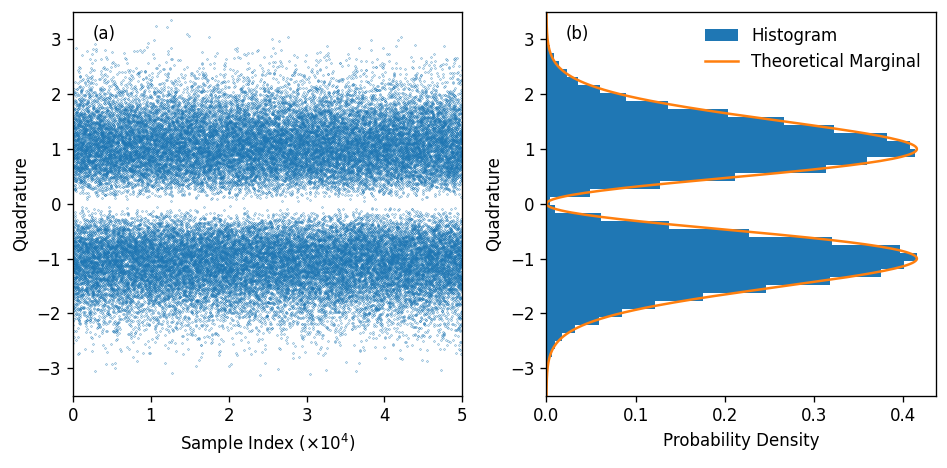

In [70]:
samples = integrate.trapezoid(traces_1photon*gen_mode, x=t, axis=1) # reconstruct quadratures

fig,ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].scatter(np.array(range(len(samples)))/10000, samples, s=0.05)
ax[0].set_ylim(-3.5,3.5)
#ax[0].set_title('Integrated Quadrature Samples')
ax[0].set_ylabel('Quadrature')
ax[0].set_xlabel(r'Sample Index ($\times 10^4$)')
ax[0].set_xlim(0,5)
ax[0].annotate('(a)', [0.05,0.93], xycoords='axes fraction')

ax[1].hist(samples, 51, orientation='horizontal', density=True, label = 'Histogram')
ax[1].plot(fock1_marge, x, label='Theoretical Marginal', color='tab:orange')
ax[1].set_ylim(-3.5,3.5)
#ax[1].set_title('Inferred Distribution')
ax[1].set_xlabel('Probability Density')
ax[1].set_ylabel('Quadrature')
ax[1].legend(frameon=False)
ax[1].annotate('(b)', [0.05,0.93], xycoords='axes fraction')
plt.rcParams['savefig.dpi'] = 300
plt.tight_layout()
plt.savefig('quads_with_hist_NEW.png')

# Wigner Function Reconstruction

We reconstruct the Wigner function subject to a range of errors in measurement. In particular, we subject measurement to a range of timing jitter values.

We reconstruct the states using Maximum-Likelihood reconstruction, and in particular we utilize the diluted $R\rho R$ method (Řeháček *et al.* (2007)) with the stopping condition derived by Glancy *et al.* (2012):
$$|\lambda_{\max}(\hat{R}) - N| < \delta$$
for some tolerance parameter $\delta$.

The following code was produced to be used in analyzing the behaviour of the method, which is why many parameters, like the number of iterations and distance to the maximal condition are returned. These can be safely neglected by calling

`rho, _, _, _ = diluted_mle_qst(...)`.



In [71]:
def generate_projector_tensor(angles, quadratures, M):
    '''
    Constructs the Pi_tensor of shape (N_data, M, M) for continuous BHD data.

    Works by evaluating the quadrature-space wavefunctions at each quadrature sample
        in every possible photon number, then computes Pi = psi_1(q)*psi_2(q) as
        a matrix of elements defined over all possible photon numbers.

    Input:
      - angles      : 1D array of phase angle samples
      - quadratures : 1D array of corresponding quadrature samples
      - M           : Fock space dimension

    Returns:
      - Pi_tensor   : (N_data, M, M) array of N_data projection operators
    '''
    # Derive quantities needed for constructing Pi matrices
    N_data = len(angles)

    # Evaluate square-normalized Hermite Polynomials to represent
    #   Fock states in the position basis
    psi_vals = np.zeros((M, N_data))
    pi_factor = np.pi ** (-0.25)
    gaussian_envelope = np.exp(-(quadratures**2) / 2.0)

    for n in range(M):
        normalization = 1.0 / np.sqrt((2**n) * factorial(n))
        hermite_eval = eval_hermite(n, quadratures)
        psi_vals[n, :] = pi_factor * normalization * hermite_eval * gaussian_envelope

    # Outer products using Einstein Summation
    psi_matrix = np.einsum('mi,ni->imn', psi_vals, psi_vals)

    # Phase shift matrix
    m_idx = np.arange(M)[:, None]
    n_idx = np.arange(M)[None, :]

    # Phase difference grid, Shape: (M, M)
    phase_diff = m_idx - n_idx

    # Compute the phase matrix for all angles
    # phase_matrix shape: (N_data, M, M)
    phase_matrix = np.exp(1j * angles[:, None, None] * phase_diff[None, :, :])

    # Obtain Pi_j matrices
    Pi_tensor = phase_matrix * psi_matrix

    return Pi_tensor


def diluted_mle_qst(Pi, frequencies, epsilon=0.1, tol=1e-5, max_iter=5000):
    """
    Execute RpR method on data to estimate a quantum state. Must pass tensors returned
        by generate_projector_tensor().

    Input:
      - Pi              : (N_data, M, M) tensor of projection operators generated by
                            generate_projector_tensor()
      - frequencies     : (N_data,) array of number of times each measurement outcome was observed.
                            For continous data, np.ones(N_data) should be used.
      - epsilon         : dilution parameter.
      - tol             : stopping condition tolerance.
      - max_iter        : maximum number of iterations.

    Returns:
      - rho_final       : qt.Qobj of the maximal density matrix.
      - distances       : list of floats representing the stopping criterion distance at each iteration.
      - log_likelihoods : list of floats representing the log-likelihood at each iteration.
    """
    # Derive quantities needed for constructing R
    N_data, M, _ = Pi.shape
    N_total = np.sum(frequencies)

    f_arr = np.array(frequencies)

    # Initial guess is a normalized identity matrix
    rho_mat = np.eye(M, dtype=complex) / M
    I_mat = np.eye(M, dtype=complex)

    # initialize lists for tracking distances and log-likelihoods
    distances = []
    log_likelihoods = []

    for k in range(max_iter):
        # Compute Tr(Pi*rho) using einstein summation
        p_arr = np.einsum('jab,ba->j', Pi, rho_mat).real # dtype complex, even if imag = 0.

        # Ensure no division by zero
        p_arr = np.clip(p_arr, 1e-15, None)

        # compute log-likelihood for tracking
        ll = np.sum(f_arr * np.log(p_arr))
        log_likelihoods.append(ll)

        # Construct likelihood operator using einstein summation
        weights = f_arr / p_arr
        R_mat = np.einsum('j,jab->ab', weights, Pi)


        # Track Distance
        R_rho = R_mat @ rho_mat
        delta = R_rho - N_total * rho_mat
        dist = np.linalg.norm(delta, ord='fro')
        distances.append(dist)


        # Check Stopping Criterion
        maxeig = eigh(R_mat, subset_by_index=[M-1, M-1], eigvals_only=True)[0]
        sc = np.abs(maxeig - N_data)


        if sc < tol:
            iters = k
            print(f"Converged successfully in {k} iterations: Distance  = {dist}")
            break

        # Dilution
        R_dil = I_mat + epsilon * R_mat

        # R * rho * R and renormalize
        rho_mat = R_dil @ rho_mat @ R_dil
        rho_mat = rho_mat / np.trace(rho_mat)

    else:
        print(f'Reached {max_iter} iterations without reaching tolerance.')
        iters = max_iter

    # Return a QuTiP Qobj instead of numpy array
    rho_final = qt.Qobj(rho_mat)
    return rho_final, distances, log_likelihoods, iters

We now take measurements and reconstruct the states.

In [72]:
N_phase_angles = 30
N_traces_per_angle = 300
cutoff_dim = 20 # Fock space cutoff dimension for density matrix reconstruction

timing_jitter_sigmas = [0, 1, 2, 5]

reconstructed_W_functions_jitter_mle = {}

rng = random.default_rng()

state_to_simulate = cat

print("Starting simulation and MLE reconstruction for various timing jitter levels...")

# 5. Iterate through each timing_jitter_sigma
for timing_jitter_sigma in timing_jitter_sigmas:
    print(f"\nProcessing timing jitter sigma = {timing_jitter_sigma}...")
    # a. Initialize empty lists for current jitter level
    all_quadratures_jittered = []
    all_phases_ideal = []

    # b. Loop through phase angles
    for i in range(N_phase_angles):
        # i. Calculate current ideal phase angle
        current_ideal_phase_angle = i * np.pi / N_phase_angles

        # ii. Obtain the CDF for the state_to_simulate at current_ideal_phase_angle
        _, _, cdf_at_ideal_phase = state_to_objects(state_to_simulate, x, p, current_ideal_phase_angle)

        # iii. Generate N_traces_per_angle photocurrent traces
        simulated_currents_batch = gen_photocurrent(modes, cdf_at_ideal_phase, bg_cdf, x, N_traces_per_angle)

        # iv. Generate timing jitter values for this batch of traces
        if timing_jitter_sigma == 0:
            tau_vals_batch = np.zeros(N_traces_per_angle)
        else:
            tau_vals_batch = rng.normal(0, timing_jitter_sigma, size=N_traces_per_angle)

        # v. Create jittered measurement modes for each trace in the batch
        meas_modes_jittered_batch = np.zeros((N_traces_per_angle, len(t)))
        for j, tau in enumerate(tau_vals_batch):
            meas_modes_jittered_batch[j, :] = gaussian_env(t, tau, 1)

        # vi. Integrate the simulated traces against the *jittered* measurement modes
        quadrature_samples_jittered = integrate.trapezoid(simulated_currents_batch * meas_modes_jittered_batch, x=t, axis=1)

        # vii. Store the jittered quadrature samples and their corresponding ideal phase angle
        all_quadratures_jittered.extend(quadrature_samples_jittered)
        all_phases_ideal.extend([current_ideal_phase_angle] * N_traces_per_angle)

    # c. Convert lists to numpy arrays
    all_quadratures_jittered = np.array(all_quadratures_jittered)
    all_phases_ideal = np.array(all_phases_ideal)

    # d. Reconstruct the density matrix using diluted_mle_qst
    print(f"  Preparing projectors and reconstructing density matrix for sigma={timing_jitter_sigma}...")

    # Generate the projector tensor for the sampled data
    Pi_tensor = generate_projector_tensor(all_phases_ideal, all_quadratures_jittered, cutoff_dim)

    # Run the diluted MLE algorithm
    # frequencies are all 1 for continuous samples
    rho_reconstructed_jittered, _, _, _ = diluted_mle_qst(Pi_tensor, np.ones(len(all_quadratures_jittered)), epsilon=1, tol=1e-5, max_iter=5000)

    # e. Compute the Wigner function for rho_reconstructed_jittered
    W_reconstructed_mle_jittered = qt.wigner(rho_reconstructed_jittered, x, p)

    # f. Store the resulting Wigner function
    reconstructed_W_functions_jitter_mle[f'sigma{int(timing_jitter_sigma)}'] = W_reconstructed_mle_jittered

print("\nAll jitter levels processed.")

# 6. Compute Wigner function for the ideal cat state and vacuum state
W_original_cat = qt.wigner(cat, x, p)
W_theoretical_vacuum = qt.wigner(bg, x, p)

print("Wigner functions for original cat state and theoretical vacuum computed.")

Starting simulation and MLE reconstruction for various timing jitter levels...

Processing timing jitter sigma = 0...
  Preparing projectors and reconstructing density matrix for sigma=0...
Converged successfully in 1034 iterations: Distance  = 1.3567571863403071e-06

Processing timing jitter sigma = 1...
  Preparing projectors and reconstructing density matrix for sigma=1...
Reached 5000 iterations without reaching tolerance.

Processing timing jitter sigma = 2...
  Preparing projectors and reconstructing density matrix for sigma=2...
Converged successfully in 725 iterations: Distance  = 9.706596925566306e-07

Processing timing jitter sigma = 5...
  Preparing projectors and reconstructing density matrix for sigma=5...
Converged successfully in 1249 iterations: Distance  = 2.841260175831944e-07

All jitter levels processed.
Wigner functions for original cat state and theoretical vacuum computed.


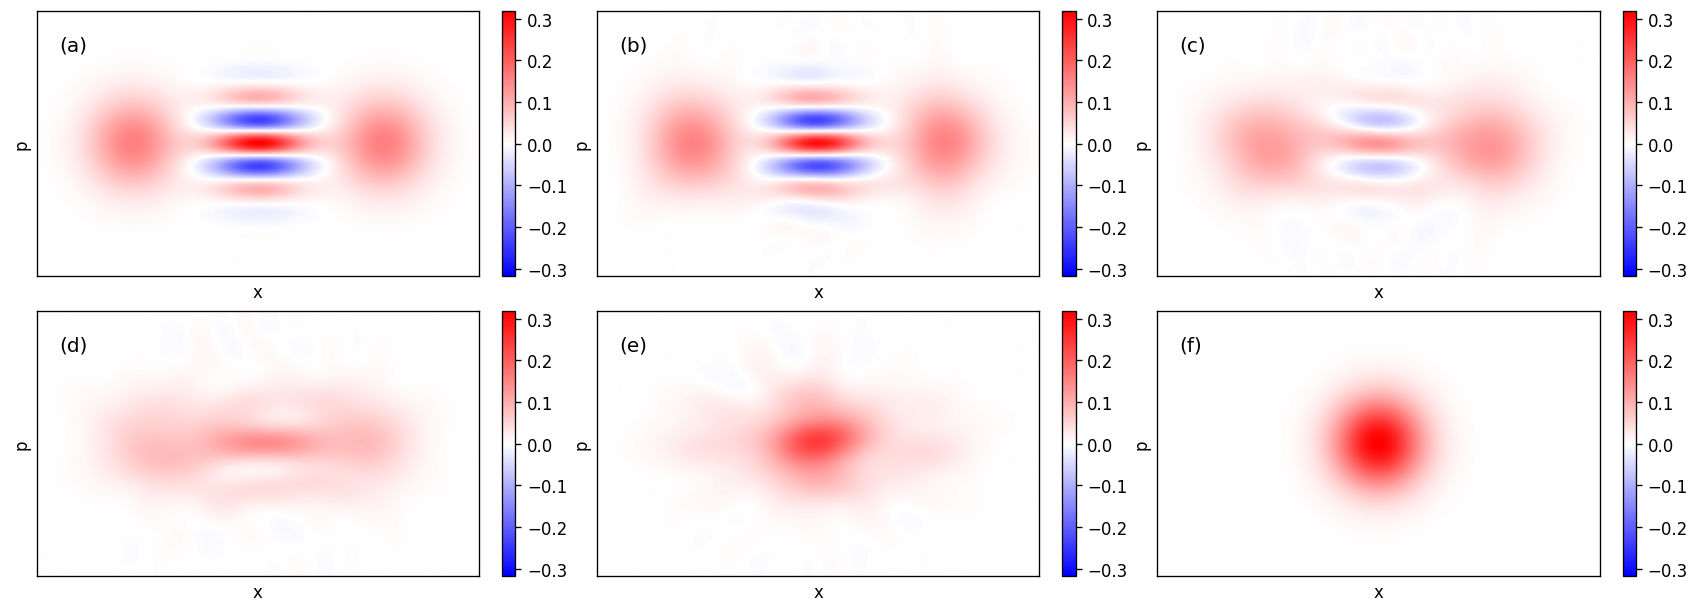

In [73]:
# Combine all Wigner functions into a single dictionary for plotting
all_w_functions_mle_jitter = {
    'Theoretical (Cat)': W_original_cat,
    r'Reconstructed ($\sigma$=0)': reconstructed_W_functions_jitter_mle['sigma0'],
    r'Reconstructed ($\sigma$=1)': reconstructed_W_functions_jitter_mle['sigma1'],
    r'Reconstructed ($\sigma$=2)': reconstructed_W_functions_jitter_mle['sigma2'],
    r'Reconstructed ($\sigma$=5)': reconstructed_W_functions_jitter_mle['sigma5'],
    'Theoretical (Vacuum)': W_theoretical_vacuum
}

num_panels = len(all_w_functions_mle_jitter)
fig, axs = plt.subplots(2, 3, figsize=(14, 5), constrained_layout=True)
axs = axs.flatten()

annotations = ['(a)','(b)','(c)','(d)','(e)','(f)']

for i, (label, W_func) in enumerate(all_w_functions_mle_jitter.items()):
    ax = axs[i]

    # Determine the min/max for symmetrical colorbar around 0
    if i == 0:
        vmax = np.max(np.abs(W_func))
        norm = colors.Normalize(vmin=-vmax, vmax=vmax)

    # Plot Wigner function with 'plasma' colormap
    im = ax.imshow(W_func, extent=[x.min(), x.max(), p.min(), p.max()], origin='lower', cmap='bwr', norm=norm)

    # Set title, labels, and colorbar
    ax.set_xlabel('x')
    ax.set_ylabel('p')
    fig.colorbar(im, ax=ax)

    ax.annotate(annotations[i], xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)

    # "Crop" the view for better visualization of features
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 3)
    ax.set_xticks([])
    ax.set_yticks([])

plt.savefig('multipanel_wigner_timingjitter.png')
plt.show()